In [3]:
import torch

if torch.cuda.is_available():
    print(f"✅ CUDA is available!")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version (Torch): {torch.version.cuda}")
else:
    print("❌ CUDA is NOT available. Check your drivers.")


✅ CUDA is available!
GPU Name: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA Version (Torch): 11.8


In [4]:

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.autograd import Function
from torchvision import datasets, transforms
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn as nn
import torch.nn.functional as F

import pennylane as qml
from pennylane import numpy as np

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

In [5]:
transformation = transforms.Compose([transforms.Resize((14,14)),
                                                       transforms.ToTensor()])

train_data = datasets.MNIST(
    root='data',
    train= True,
    transform=transformation,
    download=True
)
test_data = datasets.MNIST(
    root = 'data',
    train = False,
    transform = transformation
)

In [6]:
bach_size = 4
n_train = bach_size * 125
n_test = bach_size * 25
initial_lr = 0.003          # Define your initial learning rate
num_epochs = 40

In [7]:
n_qubits  = 4
if use_cuda is True:
    dev = qml.device("lightning.qubit", wires=n_qubits)
else:
    dev = qml.device("default.qubit", wires=n_qubits)  
    
@qml.qnode(dev)
def circute(inpute,weights):
    qml.AngleEmbedding(features=inpute,wires=range(n_qubits))
    qml.BasicEntanglerLayers(weights,wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

print(f'{dev=}')
input = torch.from_numpy(np.random.uniform(0, np.pi, (4,))).to(device)
weights = torch.from_numpy(np.random.uniform(0, np.pi, (4, 4))).to(device)
outpute = circute(input,weights)

print(f'{outpute=}')
      

dev=<lightning.qubit device (wires=4) at 0x1aea19a1910>
outpute=[tensor(0.2190), tensor(-0.1389), tensor(0.3179), tensor(0.2019)]


In [8]:
import pennylane as qml

dev1 = qml.device("default.qubit", wires=4)
print(dev1)

dev2 = qml.device("lightning.qubit", wires=4)
print(dev2)

<default.qubit device (wires=4) at 0x1aea10dcbd0>
<lightning.qubit device (wires=4) at 0x1aea1bf5950>


In [9]:
import pennylane as qml
n_channels = 4
print(qml.__version__)
print(qml.about())

0.45.0
Name: pennylane
Version: 0.45.0
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: 
Author: 
License: 
Location: c:\Users\Acer\AppData\Local\Programs\Python\Python311\Lib\site-packages
Platform info:           Windows-10-10.0.26200-SP0
Python version:          3.11.2
Numpy version:           2.2.6
Scipy version:           1.15.3
JAX version:             None
Catalyst version:        None
Installed devices:
- default.clifford (pennylane-0.45.0)
- default.gaussian (pennylane-0.45.0)
- default.mixed (pennylane-0.45.0)
- default.qubit (pennylane-0.45.0)
- default.qutrit (pennylane-0.45.0)
- default.qutrit.mixed (pennylane-0.45.0)
- default.tensor (pennylane-0.45.0)
- null.qubit (pennylane-0.45.0)
- reference.qubit (pennylane-0.45.0)
- lightning.qubit (pennylane_lightning-0.45.0)
None


In [10]:
def quanv(image,weights):
    out = np.zeros( (bach_size,4,7,7))
    l_image = image.detach().cpu().numpy()
    l_weights = weights.detach().cpu().numpy()
    for i in range(bach_size):
        for j in range(0,14,2):
            for k in range(0,14,2):
                q_result = circute (
                    [
                        l_image[i,0,j,k] *np.pi,
                        l_image[i,0,j,k+1] *np.pi,
                        l_image[i,0,j+1,k] *np.pi,
                        l_image[i,0,j+1,k+1] *np.pi,
                    ],
                    l_weights
                )
            
                for c in range(n_channels): 
                    out[i,c,j//2,k//2] = q_result[c]
    return out                   

In [16]:
class QuanConv(nn.Module):
    Layers = 4
    
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        self.weights = nn.Parameter(torch.from_numpy(np.random.uniform(
            0,np.pi,(QuanConv.Layers,n_qubits)
        )))
        
    def  forward(self,input):
        expection_z = quanv(input,self.weights)
        x = torch.tensor(expection_z).to(device)
        return x   

In [20]:
class QuantModel(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.qconv = QuanConv()
        self.fc1 = nn.Linear(4*7*7,10)
        self.double()
        
    def forward(self,x):
        x = self.qconv(x)
        x = torch.flatten(x,start_dim=1)
        x = F.relu(self.fc1(x))
        return x

In [21]:
dataset = train_data
train_size = n_train
train_set , val_set = torch.utils.data.random_split(
    dataset,[train_size,len(dataset)-train_size])

train_loder = torch.utils.data.DataLoader(
    train_set,
    bach_size,
    shuffle=True
)

for data in train_loder:
    input, lable = data
    
    print(input.shape)
    #print(input)
    
    lable = lable.repeat_interleave(n_channels)
    
    input,lable = input.to(device),lable.to(device)
    weights = torch.from_numpy(
    np.random.uniform(0, np.pi, (4, 4))
    )
    outputs = quanv(input, weights)
    outputs = torch.tensor(outputs)
    print(torch.tensor(outputs).shape)
    break



torch.Size([4, 1, 14, 14])
torch.Size([4, 4, 7, 7])


C:\Users\Acer\AppData\Local\Temp\ipykernel_3120\1813163578.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  print(torch.tensor(outputs).shape)


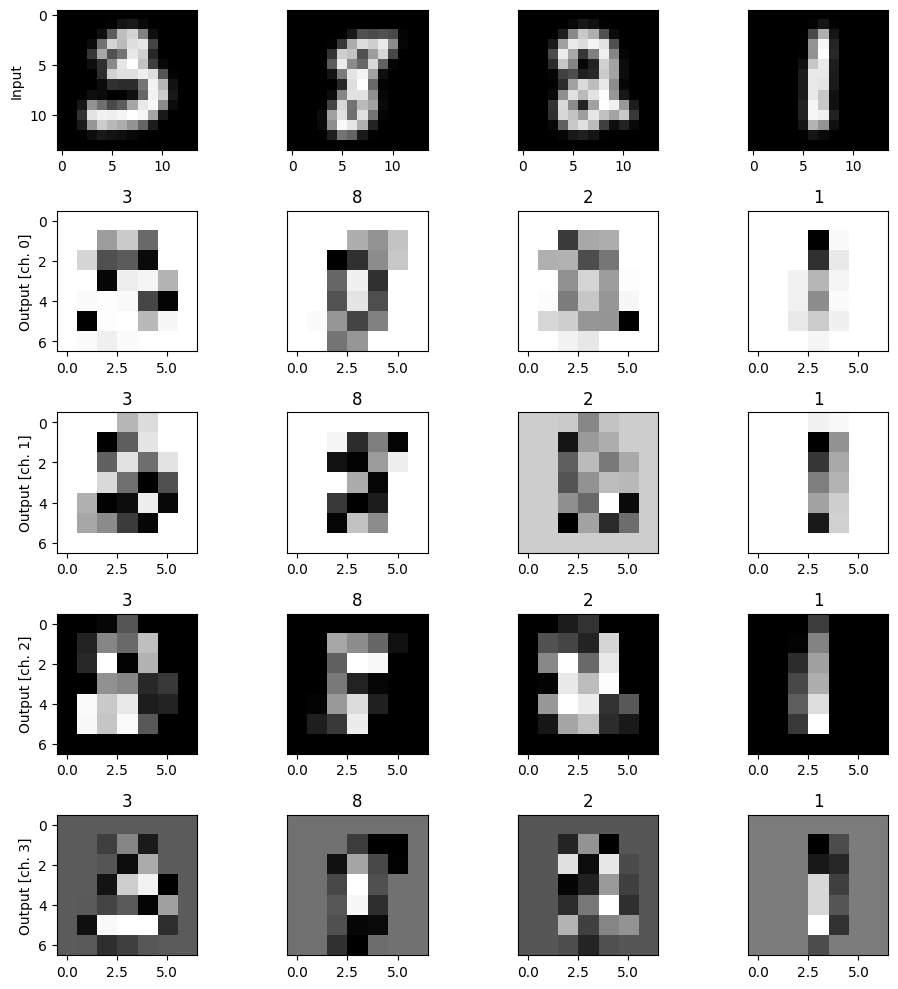

In [22]:
l_inputs = input.cpu()
n_samples = 4
n_channels = 4

fig, axes = plt.subplots(1 + n_channels, n_samples, figsize=(10, 10))

for k in range(n_samples):
    # ردیف ورودی
    axes[0, 0].set_ylabel("Input")
    if k != 0:
        axes[0, k].yaxis.set_visible(False)
    axes[0, k].imshow(l_inputs[k, 0, :, :], cmap="gray")

    # ردیف‌های خروجی
    for c in range(n_channels):
        axes[c + 1, 0].set_ylabel(f"Output [ch. {c}]")
        if k != 0:
            axes[c + 1, k].yaxis.set_visible(False)

        # فرض: label طول = n_samples * n_channels
        axes[c + 1, k].set_title(f"{lable[c + k * n_channels]}")

        axes[c + 1, k].imshow(outputs[k, c, :, :], cmap="gray")

plt.tight_layout()
plt.show()


In [23]:
import datetime
from pathlib import Path
import time

dataset = train_data

cnn = QuantModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(cnn.parameters(), lr=initial_lr,momentum=0.9)


#create a learning rate scheduler  
#Here we use a step LR scheduler that decays the learning rate by a factor of 0.1 every 10 epochs
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=1.0)

train_loader = torch.utils.data.DataLoader(train_set, shuffle=False, batch_size=bach_size)

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "ImgClass-Quanvolv.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

RESUME_TRAINING = False

if RESUME_TRAINING is True:
    print(f"Restore model state from {MODEL_SAVE_PATH}")
    model_dict = torch.load(MODEL_SAVE_PATH)
    initial_epoch = model_dict['epoch'] + 1
    cnn.load_state_dict(model_dict['model_state_dict'])
    optimizer.load_state_dict(model_dict['optimizer_state_dict'])
    loss_list = model_dict['loss'].copy()
else:
    initial_epoch = 0
    loss_list = []
    
for epoch in range(initial_epoch, num_epochs):
    cnn.train()
    ct = datetime.datetime.now()
    lr = scheduler.get_last_lr()
    print(f"{epoch=}, {lr=}, {ct}")
    running_loss = []
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()  # Zero the parameter gradients to avoid accumulation
        outputs = cnn(inputs)  # Forward pass
        loss = criterion(outputs, labels)  # Compute the loss
        loss.backward()  # Backpropagation
        running_loss.append(loss.item())
        optimizer.step()  # Update the model parameters
    loss_list.append(sum(running_loss)/len(running_loss))

    print('Training [{:.0f}%]\tLoss: {:.4f}'.format(100. * (epoch + 1) / num_epochs, loss_list[-1]))
    torch.save({
        'epoch': epoch,
        'model_state_dict': cnn.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss_list,
    }, MODEL_SAVE_PATH)
    print(f"Saving model state to {MODEL_SAVE_PATH}")

    val_loader = torch.utils.data.DataLoader(train_set, shuffle=False, batch_size=bach_size)
    correct = 0
    total = 0
    # Set the model to evaluation mode
    cnn.eval()
    with torch.inference_mode():
        for data in val_loader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = cnn(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f'Accuracy on the validation set: {100 * correct / total:.2f}%')

    # Decay Learning Rate
    scheduler.step()
print('Finished Training')
     

     
     
        
                                

epoch=0, lr=[0.003], 2026-06-13 14:55:08.630551
Training [2%]	Loss: 2.2667
Saving model state to models\ImgClass-Quanvolv.pth
Accuracy on the validation set: 26.80%
epoch=1, lr=[0.003], 2026-06-13 14:56:24.821717
Training [5%]	Loss: 2.1557
Saving model state to models\ImgClass-Quanvolv.pth
Accuracy on the validation set: 30.60%
epoch=2, lr=[0.003], 2026-06-13 14:57:38.635540
Training [8%]	Loss: 2.0696
Saving model state to models\ImgClass-Quanvolv.pth
Accuracy on the validation set: 36.20%
epoch=3, lr=[0.003], 2026-06-13 14:58:52.386391
Training [10%]	Loss: 1.9957
Saving model state to models\ImgClass-Quanvolv.pth
Accuracy on the validation set: 40.20%
epoch=4, lr=[0.003], 2026-06-13 15:00:06.973120
Training [12%]	Loss: 1.9350
Saving model state to models\ImgClass-Quanvolv.pth
Accuracy on the validation set: 42.00%
epoch=5, lr=[0.003], 2026-06-13 15:01:20.557027
Training [15%]	Loss: 1.8852
Saving model state to models\ImgClass-Quanvolv.pth
Accuracy on the validation set: 42.60%
epoch=6

KeyboardInterrupt: 